# Introduction

This notebook describes the workflow to make the recipe classifier. The goal was to take recipes from America's Test Kitchen (ATK), and train a model on the labels that were assigned to these recipes to automate the process of categorizing recipes. This would be particularly useful when assigning tags to recipes in bulk, when manually searching for individual tags can be time consuming. In this work, we collect 56 tags from ATK and create a model to assign these tags to a given recipe. Each recipe may be assigned multiple tags.

To start, I scraped the recipes from the ATK website along with their tags. I did this using Selenium and Beautiful Soup, and the exact method is described in the following section. I next preprocess the text, removing stopwords as well as lemmatizing the corpus with NLTK. With this now processed text, I establish a baseline by training a classical machine learning model on the dataset. I compare naive Bayes, logistic regression, random forest classifier, and support vector classifier (SVC), and find that the SVC gives the best results for classifying this dataset. Lastly I fine tune the Distilbert model from Hugging Face to this recipes dataset. To conserve resources on my desktop computer, I use the Low-Rank Adaptation of Large Language Models (LoRA) technique to fine tune only a subset of the parameters. Doing this fine tuning, I find that the overall performance of the Distilbert model is comparable to the performance of the classical machine learning model. That said, the performance of individual tags varies between the two models. Lastly, we explore the strengths and weaknesses of the SVC and fine tuned Distilbert models.

# Scraping from ATK

In this section, I'll go through the steps I went through to scrape the recipes from America's Test Kitchen (ATK). My goal was to scrape the recipe title, ingredient list, instructions, and recipe categories from as many recipes as possible. I'll first show how the initial list of URLs for each recipe was generated, then how the recipes themselves were scraped from the website.

This code was originally implemented in January 2025. Since then, the structure of the ATK website has changed, and this code no longer functions as a recipe scraper. To recreate this dataset, one would then need to write another scraper and have an active ATK subscription.

In [ ]:
from bs4 import BeautifulSoup
from selenium import webdriver
import pandas as pd
from tqdm import tqdm
from random import shuffle
import numpy as np

## Getting List of Recipe URLs

To obtain the list urls of the recipes, I go to the page associated with each category that ATK may assign to their recipes. I obtained this list by hand, and the scrape recipe urls from each of these category pages.

In [ ]:
from itertools import repeat

#List of categories
categories = ['main-courses','desserts-or-baked-goods','side-dishes','appetizers',
              'chicken','fruit','vegetables','pork','beef','fish-and-seafood','cheese','pasta','potatoes',
              'poultry','chocolate','beans','eggs-and-dairy','grains','rice','turkey','lamb',
              'gluten-free','vegetarian','paleo','vegan',
              'africa-and-middle-east','asia','europe','latin-america-and-caribbean','us-and-canada',
              'salads','condiments','breakfast-and-brunch','cakes','sauces','cookies','fruit-desserts','soups',
              'breads','sandwiches','beverages','stews','snacks','casseroles','dessert-pies','roasts','quick-breads',
              'puddings-custards-gelatins-and-souffles','frozen-desserts','savory-pies-and-tarts','brownies-and-bars',
              'pizza','tarts','candy','rubs','marinades']
links = ['https://www.americastestkitchen.com/recipes/'+x+'?p=27' for x in categories]
dictionary = dict(zip(categories, repeat(None)))
options = webdriver.ChromeOptions()
options.add_argument("--headless=new")
driver = webdriver.Chrome(options=options)

#Scraping the links for each category
for i in tqdm(range(len(links))):
    driver.get(links[i])
    recipe = driver.page_source
    soup = BeautifulSoup(recipe, 'html5lib')
    dummy = []
    for link in soup.find_all('li',class_="SearchCard_card__MLzqm"):
        dummy.append('https://www.americastestkitchen.com'+link.find('a').get('href'))
    dictionary[categories[i]]=dummy

recipe_links = list(set(np.concatenate(list(dictionary.values()))))
shuffle(recipe_links)

100%|██████████| 56/56 [01:23<00:00,  1.50s/it]


The urls from the above section are taken and the recipes are then scraped from each page. The recipe title, ingredients, and instructions are saved alongside the categories. 

In [ ]:
options = webdriver.ChromeOptions()
options.add_argument("--headless=new")
driver = webdriver.Chrome(options=options)
labels = []
title = []
ingredients = []
instructions = []
broken_links = []

#Scraping the recipe information for each link obtained from the previous step. 
#If the link is broken, it is added to the broken_links list and skipped.
for i in tqdm(range(len(recipe_links))):
    driver.get(recipe_links[i])
    recipe = driver.page_source
    recipe_soup = BeautifulSoup(recipe,'html5lib')
    try:
        new_label = [text for text in recipe_soup.find('ul',class_='DocumentTags_list__Yy6KB').stripped_strings if 'ATK Staff Pick' not in text]
        new_title = recipe_soup.find('h1').get_text()
        new_ingredients = recipe_soup.find('div',class_="RecipeIngredientGroup_group__B3TTL").get_text(" ")
        new_instructions = recipe_soup.find('div',class_="RecipeInstructions_recipeInstructionsList__IyXH9").get_text().replace("\n"," ")
        
        labels.append(new_label)
        title.append(new_title)
        ingredients.append(new_ingredients)
        instructions.append(new_instructions)
    except:
        broken_links.append(recipe_links[i])
    recipe_soup.decompose()

## Collecting Scraped Data and Saving File

In [ ]:
#Filtering out the broken links and combining the labels obtained from the recipe page and the category page the recipe url was originally from.
#The final dataframe is created with the combined labels, title, ingredients and instructions.
filtered_links = [item for item in recipe_links if item not in broken_links]
processed_labels = [[x.lower().replace(" ","-").replace("&","and").replace(',','') for x in y] for y in labels]
website_labels = [[cat for cat in categories if links in dictionary[cat]] for links in filtered_links]
final_label = [list(set(np.concatenate([processed_labels[i],website_labels[i]]))) for i in range(len(processed_labels))]
df = pd.DataFrame((final_label,title,ingredients,instructions)).transpose()
df[3]=df[3].replace(r'\d\.','',regex=True)

In [ ]:
#Saving the recipes dataframe to a json file for use in the training of the model.
df.to_json("atk_recipes.json",index=False)

# Getting Class Counts

In [ ]:
import pandas as pd
import os


Here, I get the number of times each tag is applied to a recipe. I only keep tags from the original list I scraped from. While there are a few others, they are only applied to a small number of recipes.

In [24]:
categories = ['main-courses','desserts-or-baked-goods','side-dishes','appetizers',
                'chicken','fruit','vegetables','pork','beef','fish-and-seafood','cheese','pasta','potatoes',
                'poultry','chocolate','beans','eggs-and-dairy','grains','rice','turkey','lamb',
                'gluten-free','vegetarian','paleo','vegan',
                'africa-and-middle-east','asia','europe','latin-america-and-caribbean','us-and-canada',
                'salads','condiments','breakfast-and-brunch','cakes','sauces','cookies','fruit-desserts','soups',
                'breads','sandwiches','beverages','stews','snacks','casseroles','dessert-pies','roasts','quick-breads',
                'puddings-custards-gelatins-and-souffles','frozen-desserts','savory-pies-and-tarts','brownies-and-bars',
                'pizza','tarts','candy','rubs','marinades']
# Loading dataset
path = os.path.dirname(os.getcwd()) + '/americas_test_kitchen_recipes_larger.json'
df = pd.read_json(path)

# Only include labels that are in the above list
abbreviated_labels = [[x for x in df[0].iloc[i] if x in categories] for i in range(len(df[0]))]
df[0]=abbreviated_labels
df = df[df[0].str.len() != 0]

The total number of recipes is a little over 12,000, which is a good number to keep in mind when looking at how many times each class has been applied

In [36]:
print(len(df))

12614


Here I plot the five most applied labels. Main courses are by far the most common tag, but all of these most frequent tags number in the thousands.

Text(0.5, 1.0, 'Top 5 Most Common Tags')

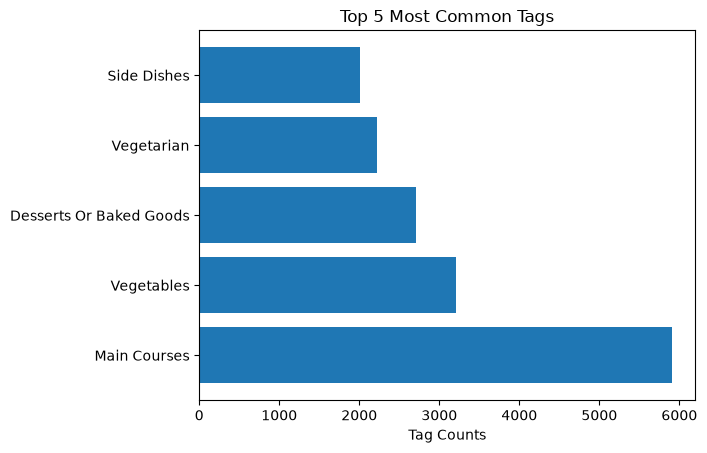

In [55]:
plt.barh(df[0].explode().value_counts().iloc[:5].index.str.replace('-',' ').str.title(),df[0].explode().value_counts().iloc[:5])
plt.xlabel('Tag Counts')
plt.title('Top 5 Most Common Tags')

These are the 5 least frequently applied tags. All of them are associated with less than 100 recipes, which creates a large class imbalance. This indicates that accuracy will not be a good metric for evaluating model performance, as simply not assigning these labels to all recipes will result in a high accuracy score. Instead, we should use either precision, recall, or an F1 score to determine how well the model is performing with these sparse labels.

Text(0.5, 1.0, 'Top 5 Least Common Tags')

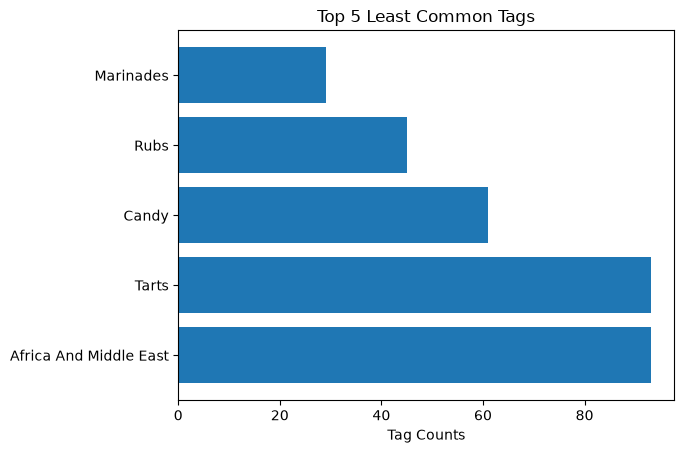

In [56]:
plt.barh(df[0].explode().value_counts().iloc[-5:].index.str.replace('-',' ').str.title(),df[0].explode().value_counts().iloc[-5:])
plt.xlabel('Tag Counts')
plt.title('Top 5 Least Common Tags')

# Benchmarking with Classical Machine Learning Models

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import sklearn.metrics as skm

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from heapq import nlargest

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from wordcloud import WordCloud

In this section, I show how the classical machine learning models are trained. The first section preprocesses recipes' text and splits the dataset into train and test sets. The following sections show each how model is trained, alongside evaluations of each model. In addition, as an example we show a word cloud for the beef tag, demonstrating which words are the strongest indicator to each model that the beef tag should be assign. In the final section, the best performing model is saved to be used later. 

## Preprocess Text

In this section, I preprocess the text by performing lemmatization, eliminating stopwords, and gettin rid of specific words that are common to all recipes. In addition, I also break the dataset into test and train sets. I also define the TF-IDF vectorizer here.

In [3]:
def clean_text(text):
  #Listing the characters/words that should be replaced in each
  REPLACE_BY_SPACE_RE = re.compile(r'[\-\(\)\{\}\[\]\/|@,;]')
  BAD_SYMBOLS_RE = re.compile('[^a-zÀ-ÿ ]')
  STOPWORDS = set(stopwords.words('english'))
  MEASUREMENTS = re.compile(r'(teaspoons?)|( table[a-z]*)|(cups?)|(ounces?)|(pounds?)|(grams?)|(chopped)|(minced)|(fresh)|(min[a-z]*)')

  # Lemmatizing and removing stopwords. Also getting rid of special additional words that prevalent in all recipes, such as measurement quantities. 
  wnl = WordNetLemmatizer()
  text = text.lower()
  text = REPLACE_BY_SPACE_RE.sub(' ', text)
  text = BAD_SYMBOLS_RE.sub('', text)
  text = MEASUREMENTS.sub('',text)
  text = ' '.join(wnl.lemmatize(word) for word in text.split() if word not in STOPWORDS) # delete stopwors from text
  return text

def preprocess_recipe(name, ingredients, instructions):     
    cleaned_text = '<T> ' + clean_text(name) + ' <I> ' + clean_text(ingredients) + ' <D> ' + clean_text(instructions)
    return cleaned_text

In [ ]:
import os

categories = ['main-courses','desserts-or-baked-goods','side-dishes','appetizers',
                'chicken','fruit','vegetables','pork','beef','fish-and-seafood','cheese','pasta','potatoes',
                'poultry','chocolate','beans','eggs-and-dairy','grains','rice','turkey','lamb',
                'gluten-free','vegetarian','paleo','vegan',
                'africa-and-middle-east','asia','europe','latin-america-and-caribbean','us-and-canada',
                'salads','condiments','breakfast-and-brunch','cakes','sauces','cookies','fruit-desserts','soups',
                'breads','sandwiches','beverages','stews','snacks','casseroles','dessert-pies','roasts','quick-breads',
                'puddings-custards-gelatins-and-souffles','frozen-desserts','savory-pies-and-tarts','brownies-and-bars',
                'pizza','tarts','candy','rubs','marinades']
# Loading dataset
path = os.path.dirname(os.getcwd()) + '/americas_test_kitchen_recipes_larger.json'
df = pd.read_json(path)

# Only include labels that are in the above list
abbreviated_labels = [[x for x in df[0].iloc[i] if x in categories] for i in range(len(df[0]))]
df[0]=abbreviated_labels
df = df[df[0].str.len() != 0]
text = [preprocess_recipe(x,y,z) for x,y,z in zip(df[1],df[2],df[3])]

#Split the datasets into test and train sets, with an 80/20 split
X_train, X_test, y_train, y_test = train_test_split(text, df[0], random_state=0,test_size=0.2)

#Binarize the tags
mlb = MultiLabelBinarizer()
y_train_binarized = mlb.fit_transform(y_train)
y_test_binarized = mlb.transform(y_test)
num_labels = len(y_train_binarized[0])

vectorizer = TfidfVectorizer()

## Training Classical Machine Learning Models

Here I show classical machine learning models which were trained and tested. For each model, I train and validate the model and create a word cloud that demonstrates which words are most associated with the "beef" category. This highlights one of the advantages of the classical machine learning models, in that they are easily interpretable and one can see quickly how they are making a classification. In addition, I also show the classification table of the test set, which gives the precision, recall, and f1 scores for each of categories. Ultimately, I find that the SVC gives the best results, so this model is saved for use in the streamlit app. A summary of the results of the other models is given in the latter section.

### Best Model: Support Vector Classifier

In [4]:
# Constructing Pipeline
model = make_pipeline(vectorizer,MultiOutputClassifier(LinearSVC(C=2)))
model.fit(X_train, y_train_binarized)
# Getting predictions on test dataset
predicted_labels = model.predict(X_test)
# Getting precision, recall, and f1 score
print(skm.precision_recall_fscore_support(y_test_binarized,predicted_labels,average='micro'))

(0.8304318026045237, 0.7197338719258644, 0.7711303462321792, None)


In the below code, I get the feature importance for the model. This tells me which words are the strongest indicators of each label. As an example, I show the 25 words which give the strongest indication a recipe should have the "Beef" tag in a word cloud, where the larger words are stronger indicators and smaller words are weaker indicators.

beef


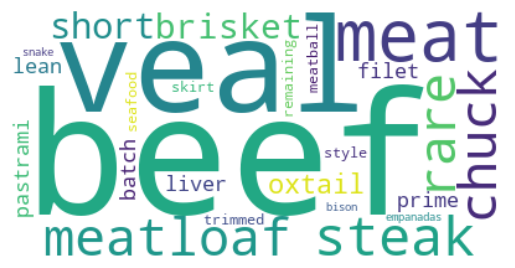

In [18]:
feat_impts = [] 
for clf in model[1].estimators_:
    feat_impts.append(clf.coef_)

classes_dictionary = dict(zip(mlb.classes_,np.arange(len(mlb.classes_))))
i = classes_dictionary['beef']

features=dict(zip(model[0].get_feature_names_out(),feat_impts[i].flatten()))
print(mlb.classes_[i])

wordcloud = WordCloud(relative_scaling=0,background_color='white').generate(' '.join(nlargest(25,features, key=features.get)))

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.margins(x=0, y=0)
plt.show()

Here is the classification table for the model. Unsurprisingly, tags that have a larger number of samples tend to have higher scores. However, this is not universal, as there are some tags that have reasonably high support, but a low score (e.g. the "Europe" tag) or tags which have a high score, but low sample size (e.g. the "Brownies and Bars" tag).

In [8]:
renaming_classes = dict(zip(np.arange(len(mlb.classes_)).astype(str),mlb.classes_))
classification_table=pd.DataFrame(skm.classification_report(y_test_binarized,predicted_labels,output_dict=True,zero_division=0
                                                           )).rename(columns=renaming_classes).transpose()
print(classification_table.to_string())

                                         precision    recall  f1-score  support
africa-and-middle-east                    0.750000  0.315789  0.444444     19.0
appetizers                                0.800000  0.467153  0.589862    137.0
asia                                      0.774194  0.551724  0.644295     87.0
beans                                     0.717647  0.628866  0.670330     97.0
beef                                      0.948598  0.939815  0.944186    216.0
beverages                                 0.983051  0.920635  0.950820     63.0
breads                                    0.833333  0.689655  0.754717     87.0
breakfast-and-brunch                      0.819048  0.716667  0.764444    120.0
brownies-and-bars                         0.947368  0.857143  0.900000     21.0
cakes                                     0.904762  0.887850  0.896226    107.0
candy                                     0.833333  0.714286  0.769231      7.0
casseroles                              

In [ ]:
# Saving the SVC model to a .pkl file for later use

from joblib import dump
with open("svc_recipes.pkl", "wb") as f:
    dump(model, f, protocol=5)
with open("mlb.pkl", "wb") as f:
    dump(mlb, f, protocol=5)

### Performance of Other Models

In [ ]:
clfs = [MultinomialNB(alpha=.0001,force_alpha=False),LogisticRegression(C=10,max_iter=1000),RandomForestClassifier(n_estimators=100,n_jobs=-1)]
scores = []
for clf in clfs:
    model = make_pipeline(vectorizer,MultiOutputClassifier(clf))
    model.fit(X_train, y_train_binarized)
    predicted_labels = model.predict(X_test)
    scores.append(skm.precision_recall_fscore_support(y_test_binarized,predicted_labels,average='micro')[:3])
scores = pd.DataFrame(scores)
scores.index = ['Naive Bayes', 'Logistic Regression', 'Random Forest']
scores.columns = ['Precision', 'Recall', 'F1 Score']

In [52]:
scores

,Precision,Recall,F1 Score
Naive Bayes,0.735988,0.603778,0.663360
Logistic Regression,0.849251,0.686705,0.759377
Random Forest,0.912191,0.486278,0.634377


We can see here that the other three models also give performance that is similar, but slightly worse than the SVC. Logistic Regression in particular is quite close to the performance of the SVC. Random forest does give excellent precision, but at the cost of a low recall score. The threshold for random forest was adjusted while exploring these results, but the results still did not surpass SVC, so the code is omitted here.

# Fine Tuning Distilbert

## Importing Data and Modules

In [60]:
import torch
import torch.optim as optim
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from transformers import Trainer,TrainingArguments
from peft import get_peft_model, LoraConfig, TaskType, PeftModel
from datasets import Dataset, Sequence, Value


if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(device)

mps


In this section, I fine tune the distilbert model on my dataset using the LoRA technique. This allows for a large improvement in the classifier while still keeping training times manageable on a consumer GPU. After this fine tuning, I find that the model gives comparable overall performance to the SVC model trained above. 

This model was trained on an RTX 3060 12GB graphics card for 30 epochs, taking roughly 1 hour to complete. 

## Creating Datasets

In [61]:
model_name = "distilbert-base-uncased"
# Applying tokenizer to the model
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
train_tokenized = tokenizer(list(X_train),truncation=True,max_length=512)
val_tokenized = tokenizer(list(X_test),truncation=True,max_length=512)

# Creating dictionaries of data from the tokenized features and the lables
train_dict = {
    "input_ids": train_tokenized["input_ids"],
    "attention_mask": train_tokenized["attention_mask"],
    "labels": y_train_binarized.tolist(),
}

test_dict = {
    "input_ids": val_tokenized["input_ids"],
    "attention_mask": val_tokenized["attention_mask"],
    "labels": y_test_binarized.tolist(),
}

# Creating HuggingFace datasets from the above dictionaries
train_dataset = Dataset.from_dict(train_dict)
val_dataset = Dataset.from_dict(test_dict)

# Converting labels from ints to floats, makes them compatible with BCEWithLogitsLoss
train_dataset = train_dataset.cast_column("labels", Sequence(Value("float32")))
val_dataset = val_dataset.cast_column("labels", Sequence(Value("float32")))

# Define a data collator, allows for dynamic padding
collator = DataCollatorWithPadding(tokenizer)

Casting the dataset:   0%|          | 0/10091 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2523 [00:00<?, ? examples/s]

## Loading Distilbert Model

In [62]:
# Loading distilbert-uncased model
model = AutoModelForSequenceClassification.from_pretrained(model_name,
                                                           num_labels=num_labels,
                                                           problem_type="multi_label_classification")
# Setting up LoRA configuration
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"],
)

# Applying LoRA configuration to the distilbert model
model = get_peft_model(model, lora_config)
model.to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): DistilBertForSequenceClassification(
      (distilbert): DistilBertModel(
        (embeddings): Embeddings(
          (word_embeddings): Embedding(30522, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (transformer): Transformer(
          (layer): ModuleList(
            (0-5): 6 x TransformerBlock(
              (attention): DistilBertSelfAttention(
                (q_lin): lora.Linear(
                  (base_layer): Linear(in_features=768, out_features=768, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=768, out_features=8, bias=False)
               

In [19]:
model.print_trainable_parameters()

trainable params: 781,112 || all params: 67,777,648 || trainable%: 1.1525


## Training Model

In [63]:
# Defining the metrics that will be used to evaluate the performance of the model. We use the f1 score rather than accuracy as there is a severe class imbalance in several tags
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = (logits > 0).astype(int)
    return {
        "f1_micro": skm.f1_score(labels, preds, average="micro", zero_division=0),
        "f1_macro": skm.f1_score(labels, preds, average="macro", zero_division=0),
    }

# Defining the training args
training_args = TrainingArguments(
    output_dir="distilbert_model/",
    num_train_epochs=30,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2, # Makes effective batch size of 32
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_steps=len(train_dataset) // 30,
    lr_scheduler_type="linear",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_micro",
    bf16=True,
    tf32=True,
    logging_steps=50,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collator,
)

ValueError: --tf32 requires Ampere or a newer GPU arch, cuda>=11 and torch>=1.7

In [ ]:
trainer.train()

## Loading Previously Trained Model

Here is where the a previously trained model is loaded. This can then be used to use get detailed performance of the validation set.

In [64]:
base_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

# Getting the pretrained model
model = PeftModel.from_pretrained(base_model, "distilbert_lora/")
model.to(device)
model.eval()

eval_args = TrainingArguments(
    output_dir="distilbert_model/",
    per_device_eval_batch_size=16,
    bf16=True,
)
trainer = Trainer(
    model=model,
    args=eval_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collator, 
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Evaluating Model Performance

In this section, I show the performance of the fine tuned Distilbert model in the same classification table format as was used for the classical machine learning models. In the section, I perform a more detailed analysis of differences between the performance of the SVC and Distilbert.

In [65]:
probabilities_val = trainer.predict(val_dataset).predictions
predicted_labels = np.where(probabilities_val>0,1,0)

/Users/davidmayrhofer/Documents/Python/Machine Learning/Recipes Project/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


In [66]:
renaming_classes = dict(zip(np.arange(len(mlb.classes_)).astype(str),mlb.classes_))

classification_table = pd.DataFrame(
    skm.classification_report(
        y_test_binarized,
        predicted_labels,
        output_dict=True,
        zero_division=0)
).rename(columns=renaming_classes).transpose()

print(classification_table.to_string())

                                         precision    recall  f1-score  support
africa-and-middle-east                    0.666667  0.315789  0.428571     19.0
appetizers                                0.827586  0.350365  0.492308    137.0
asia                                      0.780488  0.735632  0.757396     87.0
beans                                     0.734694  0.742268  0.738462     97.0
beef                                      0.920930  0.916667  0.918794    216.0
beverages                                 0.948276  0.873016  0.909091     63.0
breads                                    0.797297  0.678161  0.732919     87.0
breakfast-and-brunch                      0.784314  0.666667  0.720721    120.0
brownies-and-bars                         0.823529  0.666667  0.736842     21.0
cakes                                     0.867925  0.859813  0.863850    107.0
candy                                     0.571429  0.571429  0.571429      7.0
casseroles                              

# Comparing Fine Tuned Distilbert Classifier with SVC

In this section, I show how both models compare in each tag. The overall model performance is similar, but each individual tag may perform fairly different depending on the model chosen. 

In [67]:

from joblib import load

# Load the SVC model

with open("svc_recipes.pkl", "rb") as f:
    model = load(f)

predicted_labels_svc = model.predict(X_test)
classification_table_svc = pd.DataFrame(
    skm.classification_report(
        y_test_binarized,
        predicted_labels_svc,
        output_dict=True,
        zero_division=0)
).rename(columns=renaming_classes).transpose()

Text(0.5, 1.0, 'Per Tag F1 Score Difference Between SVC and DistilBERT')

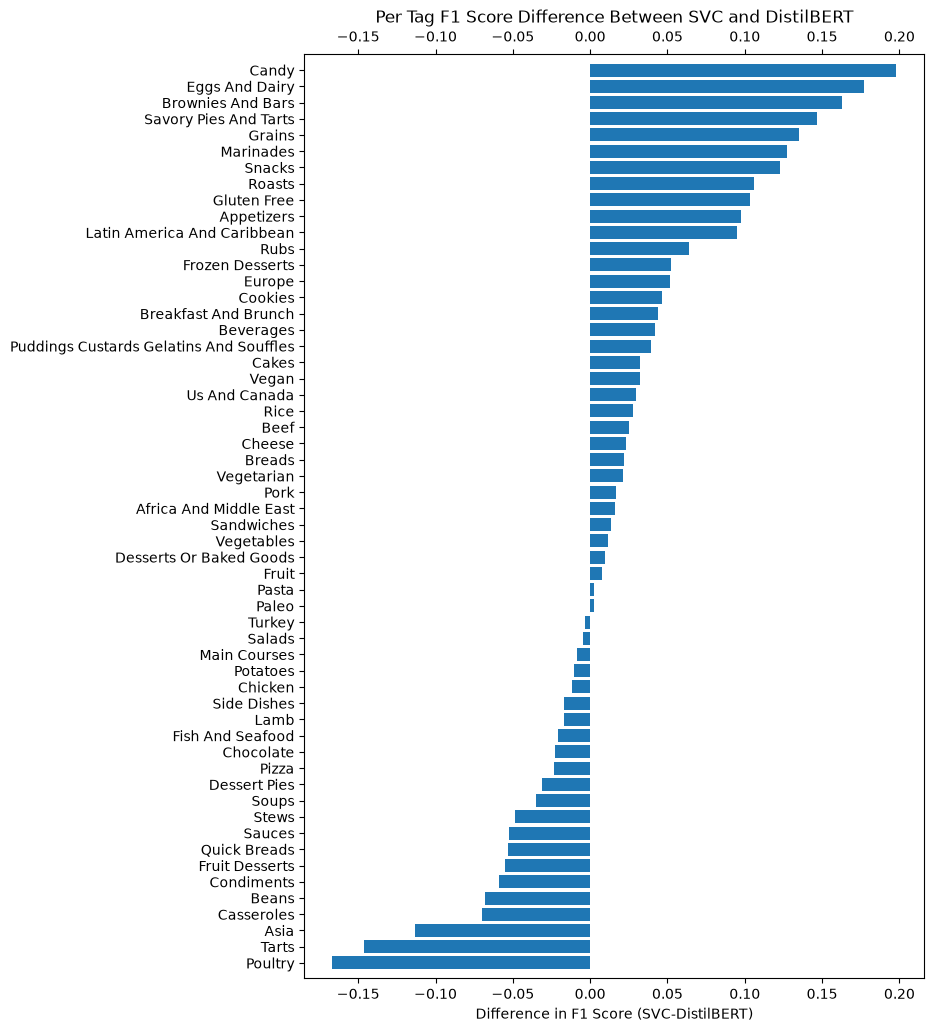

In [68]:
fig, ax = plt.subplots(figsize=(8, 12))
delta_f1 = (((classification_table_svc-classification_table))[:-4]).sort_values(by='f1-score')['f1-score']
tags = delta_f1.index.str.replace('-',' ').str.title()
ax.barh(tags,delta_f1)
ax.margins(y=.01)
ax.tick_params(top=True, labeltop=True, bottom=True, labelbottom=True)
ax.set_xlabel('Difference in F1 Score (SVC-DistilBERT)')
ax.set_title('Per Tag F1 Score Difference Between SVC and DistilBERT')

# Conclusions

The above results indicate that the SVC and Distilbert models perform overall similarly. In some sense, this may seem surprising, as the Distilbert model is significantly more sophisticated model than the much older SVC. There are several reasons this may be the case.

1. The tags are applied to the recipes by many different individuals, which may lead to inconsistencies in how they are applied. For instance, many dessert recipes are vegetarian, but whether they are actually labeled as vegetarian is inconsistent. This will confuse both classical and deep learning models.

2. There are many labels which suffer from severe class imbalance. For instance, the "Candy" tag is only applied to 61 recipes. This may be in part due to the inconsistent labeling described above, but also may be a result of some recipes being genuinely underrepresented. 

3. Deep learning models benefit more strongly from large datasets that classical machine learning models. While this dataset contains more than 10K recipes, deep learning models often see larger improvement as the size of the dataset increases to 50K or 100K samples as compared to a classical machine learning model.

I will also note that a per-category threshold tuning was done. However, this led to only marginal improvements to performance. Since this risks overfitting while also only providing a minimal improvements, the standard threshold was kept. This indicates that the less performant tags most likely had a poor AUC score, but more work would need to be done to confirm if this is really true.

In my opinion, the most beneficial course of action would be a thorough cleaning of the dataset to ensure that labels are applied in a consistent manner. This would ensure that the models are learning the "correct" labels, which should improve the performance of the model in both scenarios. That said, such a task would either require a fair amount of human resources alongside a clear rubric to assign labels, or additional machine learning tools to determine similarities between recipes in a kind of unsupervised learning.